# Summary

This notebook contains a summary of the entire repository for the BNPL project

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys, os, glob
import re
import math
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from shapely.geometry import Point
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, LongType, IntegerType, DateType, DoubleType
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from pathlib import Path


In [3]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/10 14:05:17 WARN Utils: Your hostname, tray, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/10/10 14:05:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/10 14:05:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Preprocessing

On preprocessing all the data the following records are left in the dataset

In [4]:
# merchant data set
df_merchants = spark.read.parquet('.././data/curated/df_merchants')
df_merchants.count()

4026

In [5]:
# consumer fraud probability
df_customers = spark.read.parquet('.././data/curated/consumer_fraud_probability')
df_customers_demo = spark.read.parquet('../data/curated/df_customers_demo')
df_customers.count()

34864

In [6]:
df_customers_demo.count()

499999

In [7]:
# full transactions (after join w merchant and consumers)
df_transactions = spark.read.parquet('.././data/curated/df_transactions')
df_transactions.count()

13614675

All tables have been checked to ensure that all records are valid. Invalid merchants were removed.

Joining the original data:
The data was joined on order_datetime and ids for merchants and consumers

In [8]:
df_transactions.printSchema()

root
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)



In [9]:
df_transactions.filter(F.isnull('avg_merchant_fraud_prob')).count()

13031129

In [10]:
df_transactions.filter(F.isnull('fraud_probability')).count()

13543038

13031129 merchant frauds were null and 13543038 consumer frauds were null and needed to be imputed.

## External datasets:
**Census Data:** This data was combined with our original data using consumer postocde and was used to retrieve features such as household size, family earnings and age.

In [11]:
final_merged = spark.read.parquet('.././data/curated/final_external_enriched')
final_merged.show()

+--------------+--------+------------+-------+------------------+--------------------+-----------+-----------------+--------------------+-----+------+------------------+---------------------+--------------------+--------------------+--------------------+------------+---------+-------------------+------------------+--------------+------------------+-----------------------+------------------+-----------------------------+---------------------------+------------------+-------------------------+----------------------------+-------------------------+----------------------+-------------------+--------------+------------------+----------------+------------------+---------------+------------------+--------------+------------------+--------------+-----------------+---------------+-----------------+
|order_datetime|postcode|merchant_abn|user_id|      dollar_value|            order_id|consumer_id|             name|             address|state|gender| fraud_probability|is_same_day_duplicate|       m

In [12]:
final_merged.printSchema()

root
 |-- order_datetime: date (nullable = true)
 |-- postcode: string (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)
 |-- Me

In [13]:
final_merged.select(
    F.count("*").alias("total_rows"),
    F.sum(F.col("Median_age_persons").isNull().cast("int")).alias("missing_census"),
    F.sum(F.col("poa_irsad_score").isNull().cast("int")).alias("missing_seifa"),
    F.sum(F.col("rba_cash_rate_pct").isNull().cast("int")).alias("missing_rba"),
    F.sum(F.col("avg_merchant_fraud_prob").isNull().cast("int")).alias("missing_fraud_label"),
).show()

+----------+--------------+-------------+-----------+-------------------+
|total_rows|missing_census|missing_seifa|missing_rba|missing_fraud_label|
+----------+--------------+-------------+-----------+-------------------+
|  13614675|       2244225|      2329646|          0|           13031129|
+----------+--------------+-------------+-----------+-------------------+



# Summary for Final Ranking
This section summarises how the merchants were ranked and what we found. 

In [14]:
CURATED = Path("../data/curated")

ranked = pd.read_parquet(CURATED / "final_ranking.parquet")
ranked["merchant_abn"] = ranked["merchant_abn"].astype(str)
excluded = pd.read_csv(CURATED / "excluded_merchants.csv", dtype={"merchant_abn": str})

# merchant names, to make the tables readable
names = spark.read.parquet("../data/curated/df_merchants").select("merchant_abn", "merchant_name").toPandas()
names["merchant_abn"] = names["merchant_abn"].astype(str)
ranked = ranked.merge(names, on="merchant_abn", how="left")

top100 = ranked[ranked["final_rank"] <= 100].sort_values("final_rank")
top10 = ranked[ranked["final_rank_in_segment"] <= 10].sort_values(["segment", "final_rank_in_segment"])
print("Ranked merchants:", len(ranked), "| excluded:", len(excluded))

Ranked merchants: 3569 | excluded: 457


## How the ranking works
The ranking is built around the revenue each merchant generates for BNPL (`take rate × dollar value`). In addition, we consider the following factors:

**Eligibility**

Merchants with fewer transactions than 30 and merchants with a high recorded fraud probability, are not ranked.

**Features with positive score**

    - Revenue

    - Demand: weights depend in each segments.

    - Essential products: demands for these products should be more stable.

    - Customer demographics: customers that are younger and their area is more disadvantaged are preferred. Also, customers from areas with high mortgage are less preferred.
    
**Fraud probability** 

        - Merchants that had high fraud probability are removed.
        
        - Flagged merchants are penalised by its probability of being fraud.

        - We also penalise for consumers, by getting the fraud rate.

We then combine the penalisation for merchant fraud and consumer fraud, and this is defined as the fraud score.

                          revenue  demand  essential  demographics  \
segment                                                              
Vehicles & Equipment        0.878   0.062      0.029          0.03   
Leisure, Gifts & Art        0.847   0.094      0.029          0.03   
Home & Office               0.826   0.115      0.029          0.03   
Fashion, Beauty & Luxury    0.775   0.166      0.029          0.03   
Technology & Media          0.753   0.188      0.029          0.03   

                          fraud penalty  
segment                                  
Vehicles & Equipment             -0.145  
Leisure, Gifts & Art             -0.145  
Home & Office                    -0.145  
Fashion, Beauty & Luxury         -0.145  
Technology & Media               -0.145  


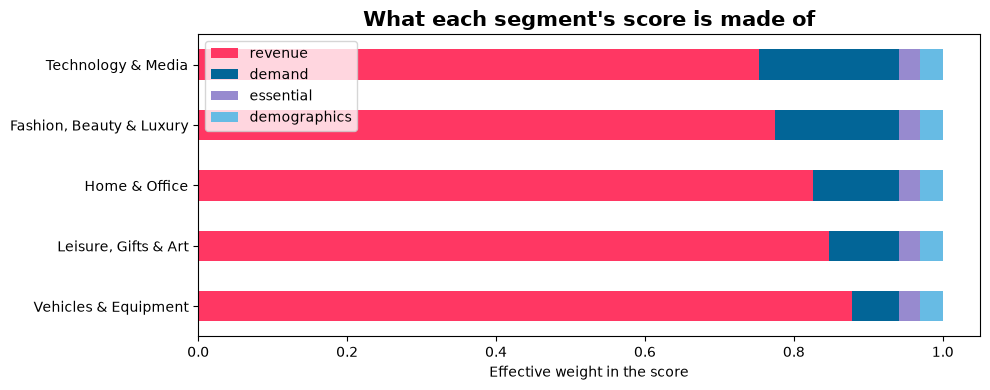

In [15]:
# Show all weighted scores and the final score 
W_ESS, W_DEMO = 0.03, 0.03                     # chosen in final_ranking.ipynb
has_fraud = ranked["fraud_score"] > 0          # fraud weight recovered from the saved scores
W_FRAUD = ((ranked["score_w2"] - ranked["final_score"]) / ranked["fraud_score"])[has_fraud].median()

seg_w = ranked.groupby("segment")["demand_weight"].first()
k = (1 - W_ESS) * (1 - W_DEMO)
effective = pd.DataFrame({
    "revenue": k * (1 - seg_w),
    "demand": k * seg_w,
    "essential": (1 - W_DEMO) * W_ESS,
    "demographics": W_DEMO,
    "fraud penalty": -W_FRAUD,
}).sort_values("demand")
print(effective.round(3))

ax = effective.drop(columns="fraud penalty").plot.barh(stacked=True, figsize=(10, 4), color=("#FF3763", "#026597", "#978ACF", "#67BBE4"))
ax.set_xlabel("Effective weight in the score")
ax.set_ylabel("", fontsize = 20)
ax.set_title("What each segment's score is made of", fontsize=15, fontweight="bold")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

Revenue is what determines most of the score. As you can see, demand will vary depending on the segment. Demand weighs less in Vehicles & Equipment, Leisure and Home & Office, where merchants sell fewer but more expensive items. The business rules have lower weight, since it was seen that the effect between merchants does not change.

# Top 100 merchants

In [16]:
cols = ["final_rank", "merchant_name", "merchant_abn", "segment", "category_group",
        "est_revenue", "num_transactions", "fraud_score"]
print(top100[cols].round({"est_revenue": 0, "fraud_score": 4}).to_string(index=False))

 final_rank                     merchant_name merchant_abn                  segment      category_group  est_revenue  num_transactions  fraud_score
          1                    Ornare Limited  96680767841     Vehicles & Equipment             vehicle     579578.0             31134       0.0032
          2     Dignissim Maecenas Foundation  48534649627 Fashion, Beauty & Luxury       health_beauty     624755.0             66437       0.0066
          3                 Leo In Consulting  86578477987 Fashion, Beauty & Luxury             jewelry     613411.0            272674       0.0087
          4              Mauris Non Institute  21439773999       Technology & Media    tv_media_telecom     575026.0            120624       0.0070
          5                  Lacus Consulting  45629217853     Leisure, Gifts & Art gifts_hobby_novelty     585975.0            228255       0.0089
          6     Orci In Consequat Corporation  32361057556     Leisure, Gifts & Art gifts_hobby_novelty     6236

In [17]:
cols = {"final_rank": "Rank", "merchant_name": "Merchant", "segment": "Segment",
        "est_revenue": "Revenue for BNPL", "num_transactions": "Transactions"}
table = top100.sort_values("final_rank")[list(cols)].rename(columns=cols)
(table.style
      .hide(axis="index")
      .format({"Revenue for BNPL": "${:,.0f}", "Transactions": "{:,.0f}"}))

Rank,Merchant,Segment,Revenue for BNPL,Transactions
1,Ornare Limited,Vehicles & Equipment,"$579,578","31,134"
2,Dignissim Maecenas Foundation,"Fashion, Beauty & Luxury","$624,755","66,437"
3,Leo In Consulting,"Fashion, Beauty & Luxury","$613,411","272,674"
4,Mauris Non Institute,Technology & Media,"$575,026","120,624"
5,Lacus Consulting,"Leisure, Gifts & Art","$585,975","228,255"
6,Orci In Consequat Corporation,"Leisure, Gifts & Art","$623,617","85,780"
7,Est Nunc Consulting,"Leisure, Gifts & Art","$535,420","215,963"
8,Lobortis Ultrices Company,"Leisure, Gifts & Art","$559,914","113,541"
9,Amet Risus Inc.,Home & Office,"$663,870","4,798"
10,Dictum Phasellus In Institute,"Leisure, Gifts & Art","$515,033","99,176"


We can see that merchant revenue isn't the only factor determining the ranking. For instance, Dignissim Maecenas Foundation is in second position, even though its revenue is higher than Ornare Limited. This has to do with the weight we gave to demand, since Dignissim Maecenas Foundation comes from Fashion, Beauty & Luxury; demand will have a higher weight than in Vehicles & Equipment.

                          top 100 (%)  all ranked merchants (%)
segment                                                        
Vehicles & Equipment             11.0                      10.4
Fashion, Beauty & Luxury         13.0                      19.4
Home & Office                    20.0                      17.7
Technology & Media               23.0                      27.0
Leisure, Gifts & Art             33.0                      25.6


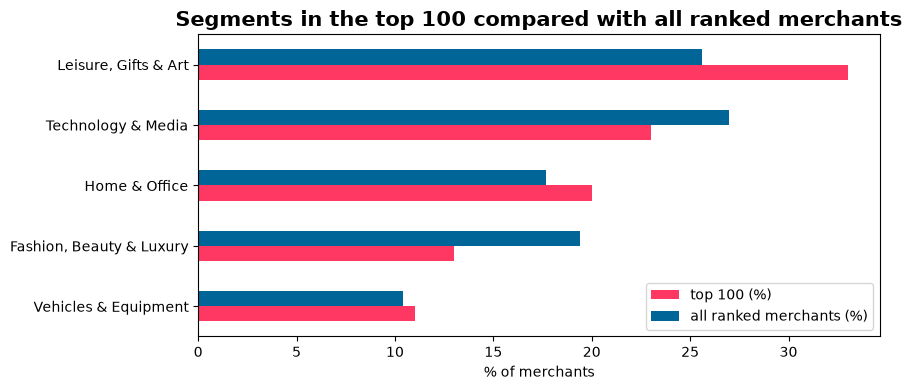

In [ ]:
seg = pd.DataFrame({
    "top 100 (%)": top100["segment"].value_counts(normalize=True) * 100,
    "all ranked merchants (%)": ranked["segment"].value_counts(normalize=True) * 100,
}).round(1).sort_values("top 100 (%)")
print(seg)

ax = seg.plot.barh(figsize=(9, 4), color=("#FF3763", "#026597"))
ax.set_xlabel("% of merchants")
ax.set_ylabel("")
ax.set_title("Segments in the top 100 compared with all ranked merchants", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

All five segments are represented in the top 100. Leisure, Gifts & Art (33%), Home & Office (20%) and Vehicles & Equipment (11%) have more high-revenue merchants than average. Fashion, Beauty & Luxury (13%) and Technology & Media (23%) are under-represented, since they have many small merchants.

# Top 5 merchants overall

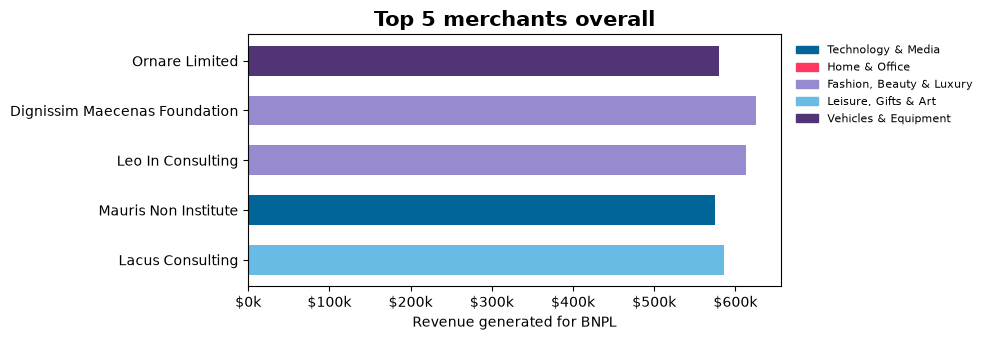

In [22]:
# one colour per segment, the same in every chart
SEGMENT_COLORS = {
    "Technology & Media": "#026597",
    "Home & Office": "#FF3763",
    "Fashion, Beauty & Luxury": "#978ACF",
    "Leisure, Gifts & Art": "#67BBE4",
    "Vehicles & Equipment": "#503473",
}

top5_overall = top100.nsmallest(5, "final_rank").sort_values("final_rank", ascending=False)   # best at the top
labels = top5_overall["merchant_name"].fillna(top5_overall["merchant_abn"]).str.slice(0, 30)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.barh(labels, top5_overall["est_revenue"], color=top5_overall["segment"].map(SEGMENT_COLORS), height=0.6)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x / 1000:,.0f}k"))
ax.set_xlabel("Revenue generated for BNPL")
ax.set_title("Top 5 merchants overall", fontsize=15, fontweight="bold")
ax.legend(handles=[Patch(color=c, label=s) for s, c in SEGMENT_COLORS.items()],
          loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [23]:
top5_overall

,merchant_abn,take_rate,total_dollar_value,num_transactions,est_revenue,score_revenue,score_demand,category_group,segment,avg_purchase_value,...,share_low_advantage,share_high_mortgage,score_demographics,score_w2,merchant_fraud_score_final,fraud_score,final_score,final_rank,final_rank_in_segment,merchant_name
4,45629217853,6.98,8.395062e+06,228255,585975.359861,0.988545,0.981096,gifts_hobby_novelty,"Leisure, Gifts & Art",36.779315,...,0.306487,0.332937,0.401759,0.941474,NaN,0.008870,0.940191,5,1,Lacus Consulting
3,21439773999,6.10,9.426657e+06,120624,575026.049193,0.986813,0.930381,tv_media_telecom,Technology & Media,78.149096,...,0.305617,0.333261,0.401022,0.944454,0.285045,0.007006,0.943441,4,1,Mauris Non Institute
2,86578477987,6.43,9.539823e+06,272674,613410.604296,0.992744,0.995235,jewelry,"Fashion, Beauty & Luxury",34.986184,...,0.303463,0.333024,0.400140,0.946492,NaN,0.008738,0.945228,3,2,Leo In Consulting
1,48534649627,6.64,9.408958e+06,66437,624754.832497,0.994426,0.882956,health_beauty,"Fashion, Beauty & Luxury",141.622264,...,0.304941,0.332986,0.400983,0.958242,0.285679,0.006620,0.957285,2,1,Dignissim Maecenas Foundation
0,96680767841,5.91,9.806731e+06,31134,579577.811170,0.987537,0.822685,vehicle,Vehicles & Equipment,314.984620,...,0.305410,0.331930,0.401096,0.960006,0.295552,0.003176,0.959547,1,1,Ornare Limited


Two merchants in Fashion, Beauty & Luxury are inside the top 5, one sells jewlery and the other one health beuty items. 

# Demographics across top 100 merchants

                            Top 100  Other merchants
Younger areas                 32.74            32.67
Higher disadvantage (IRSD)    30.51            30.63
Lower advantage (IRSAD)       30.57            30.62
Higher mortgage cost          33.22            33.20


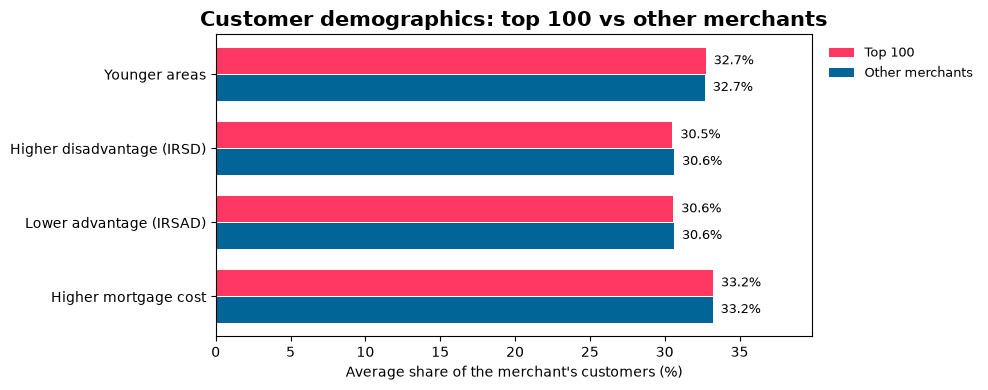

In [24]:
demo_cols = {
    "share_young": "Younger areas",
    "share_disadvantage": "Higher disadvantage (IRSD)",
    "share_low_advantage": "Lower advantage (IRSAD)",
    "share_high_mortgage": "Higher mortgage cost",
}
in_top = ranked["final_rank"] <= 100
demo_comp = pd.DataFrame({
    "Top 100": ranked.loc[in_top, list(demo_cols)].mean(),
    "Other merchants": ranked.loc[~in_top, list(demo_cols)].mean(),
}).rename(index=demo_cols) * 100
print(demo_comp.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
y = np.arange(len(demo_comp))
ax.barh(y - 0.18, demo_comp["Top 100"], height=0.35, color="#FF3763", label="Top 100")
ax.barh(y + 0.18, demo_comp["Other merchants"], height=0.35, color="#026597", label="Other merchants")
for i, (a, b) in enumerate(zip(demo_comp["Top 100"], demo_comp["Other merchants"])):
    ax.text(a, i - 0.18, f"  {a:.1f}%", va="center", fontsize=9)
    ax.text(b, i + 0.18, f"  {b:.1f}%", va="center", fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels(demo_comp.index)
ax.invert_yaxis()
ax.set_xlim(0, demo_comp.values.max() * 1.2)
ax.set_xlabel("Average share of the merchant's customers (%)")
ax.set_title("Customer demographics: top 100 vs other merchants", fontsize=15, fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

As seen before, the top 100 has practically the same customer demographics as the other merchants.

# Top 10 merchants per segment

In [25]:
for s, g in top10.groupby("segment"):
    print(f"\n=== {s} ===")
    print(g[["final_rank_in_segment", "final_rank", "merchant_name", "merchant_abn", "category_group",
             "est_revenue", "num_transactions"]].round({"est_revenue": 0}).to_string(index=False))


=== Fashion, Beauty & Luxury ===
 final_rank_in_segment  final_rank                 merchant_name merchant_abn category_group  est_revenue  num_transactions
                     1           2 Dignissim Maecenas Foundation  48534649627  health_beauty     624755.0             66437
                     2           3             Leo In Consulting  86578477987        jewelry     613411.0            272674
                     3          20   Gravida Mauris Incorporated  49322182190        jewelry     498791.0             51903
                     4          30   Suspendisse Dui Corporation  46804135891  health_beauty     206350.0            234434
                     5          32            Dolor Quisque Inc.  93558142492       footwear     301850.0             21838
                     6          34                Blandit At LLC  11439466003       footwear     278809.0             29888
                     7          59                Sociosqu Corp.  99976658299       footwear     2

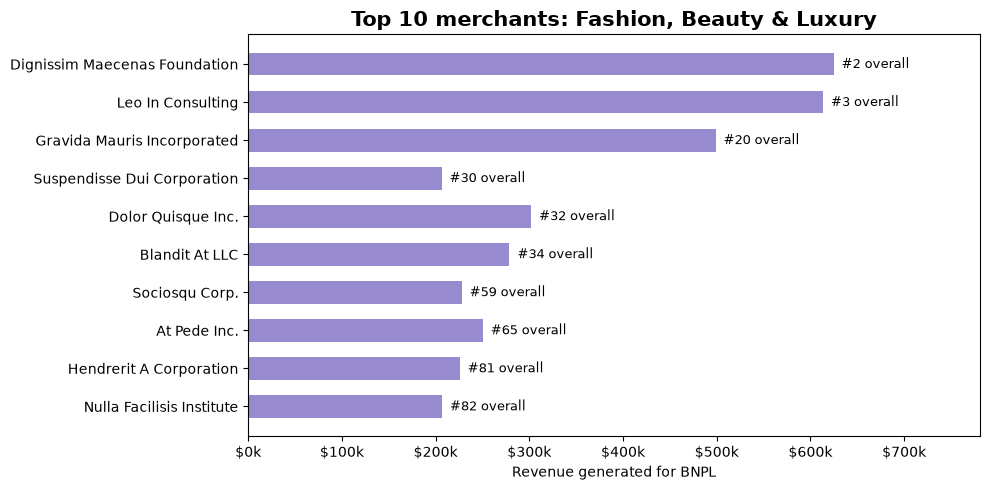

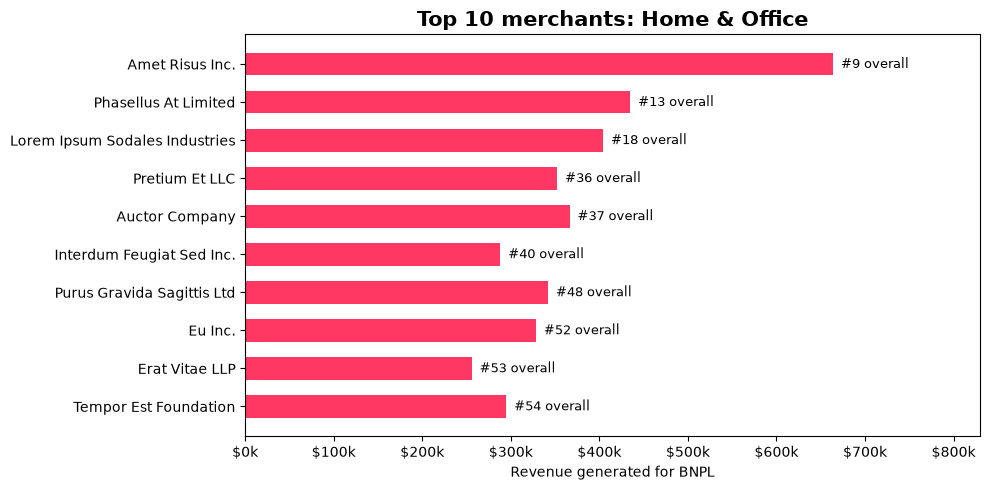

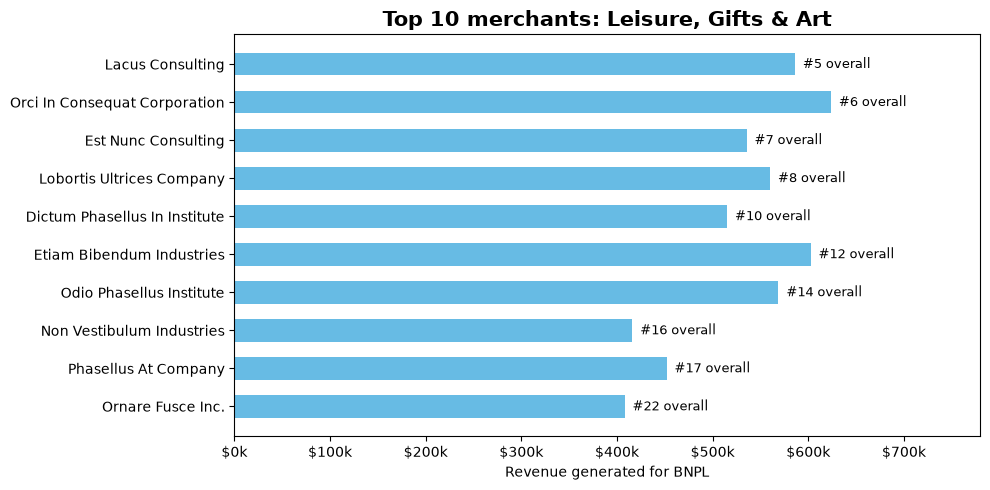

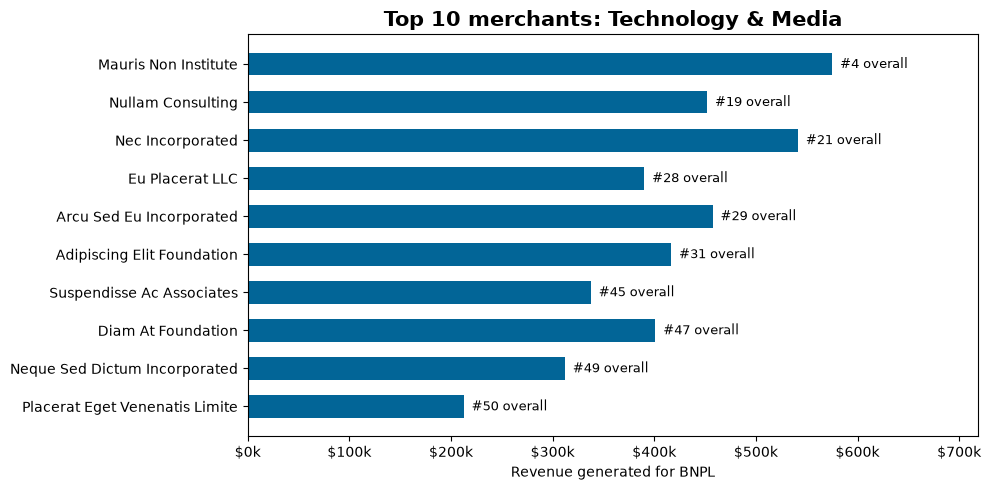

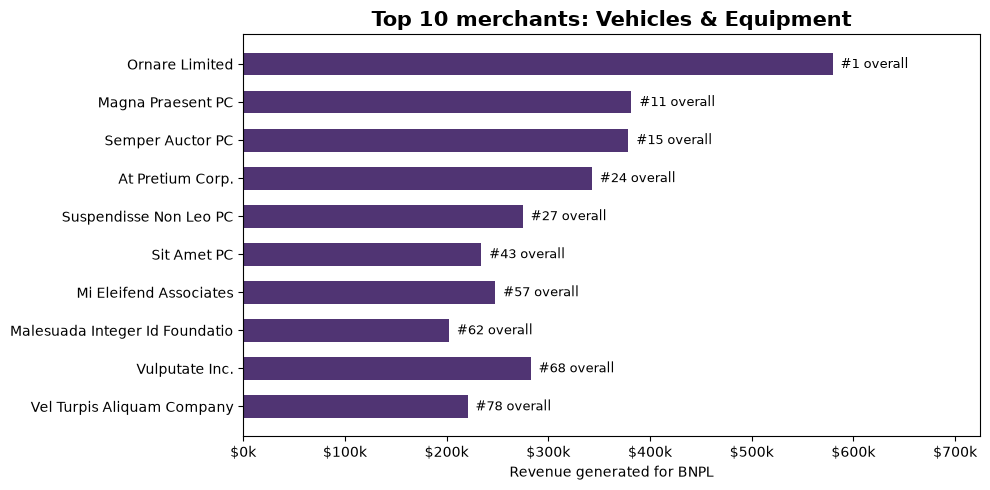

In [26]:
for seg, g in top10.groupby("segment"):
    g = g.sort_values("final_rank_in_segment", ascending=False)      # best merchant at the top
    labels = g["merchant_name"].fillna(g["merchant_abn"]).str.slice(0, 30)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(labels, g["est_revenue"], color=SEGMENT_COLORS.get(seg, "#4C72B0"), height=0.6)
    for bar, rank in zip(ax.patches, g["final_rank"]):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f"  #{rank} overall", va="center", fontsize=9)
    ax.set_xlim(0, g["est_revenue"].max() * 1.25)                    # room for the labels
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x / 1000:,.0f}k"))
    ax.set_xlabel("Revenue generated for BNPL")
    ax.set_title(f"Top 10 merchants: {seg}", fontsize=15, fontweight="bold")
    plt.tight_layout()


Check if business rules and fraud penalty affect the recommendations.

Top 100 also in the top 100 by revenue alone:           95
Top 100 also in the top 100 with revenue + demand only:  98
Merchants flagged as fraud in the top 100:              0
Merchants flagged as fraud in the segment top 10s:      0
Consumer fraud rate, top 100: 0.47% | other merchants: 0.66%


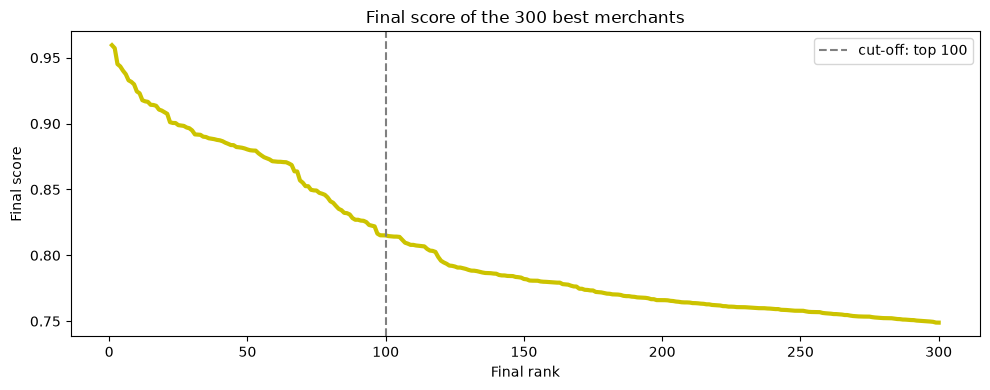

In [27]:
initial_top = set(ranked.loc[ranked["rank_overall"] <= 100, "merchant_abn"])
revenue_top = set(ranked.nlargest(100, "est_revenue")["merchant_abn"])
final_top = set(top100["merchant_abn"])
others = ranked[ranked["final_rank"] > 100]

print("Top 100 also in the top 100 by revenue alone:          ", len(final_top & revenue_top))
print("Top 100 also in the top 100 with revenue + demand only: ", len(final_top & initial_top))
print("Merchants flagged as fraud in the top 100:             ", int((top100["is_fraud_merchant"] == 1).sum()))
print("Merchants flagged as fraud in the segment top 10s:     ", int((top10["is_fraud_merchant"] == 1).sum()))
print(f"Consumer fraud rate, top 100: {top100['consumer_fraud'].sum() / top100['consumer_labelled'].sum():.2%}"
      f" | other merchants: {others['consumer_fraud'].sum() / others['consumer_labelled'].sum():.2%}")

scores = ranked.sort_values("final_rank")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(scores["final_rank"].head(300), scores["final_score"].head(300), color = "#CCC300", linewidth = 3)
ax.axvline(100, color="grey", linestyle="--", label="cut-off: top 100")
ax.set_xlabel("Final rank")
ax.set_ylabel("Final score")
ax.set_title("Final score of the 300 best merchants")
ax.legend()
plt.tight_layout()
plt.show()

The curve shows how far apart the merchants are. The top merchants have a more decisive final rank. However, when the scores reach 0.8, the merchants have almost the same score. Therefore, the last merchants in the top 100 could be replaced by others outside if the BNPL company needs to.

# Interesting merchants

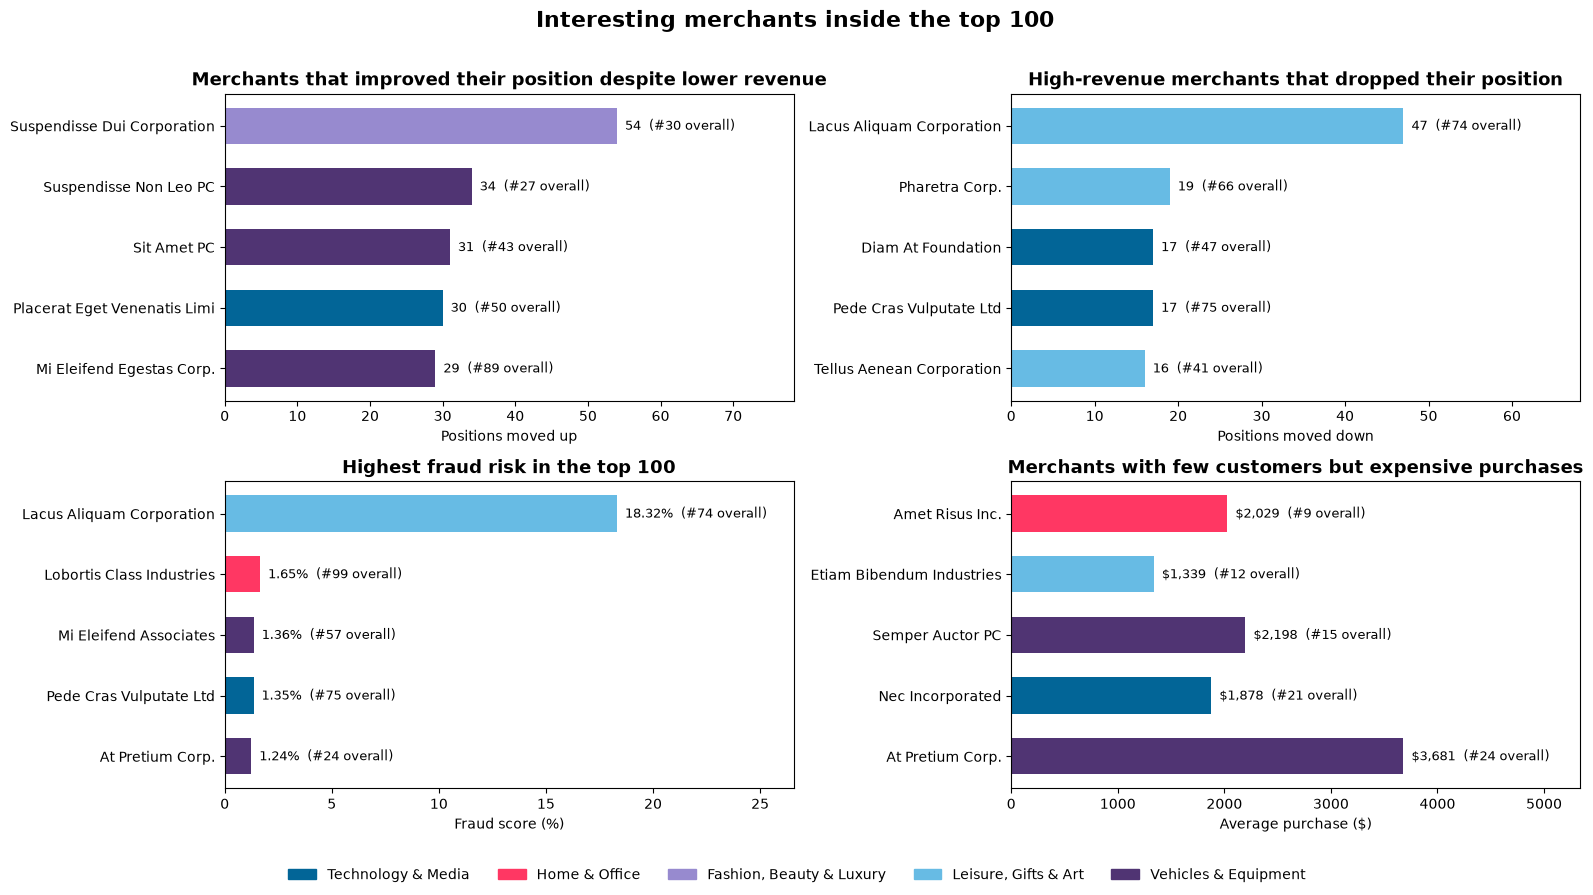

In [31]:
# final top 100, with its position by revenue alone for comparison
r = ranked.copy()
r["revenue_rank"] = r["est_revenue"].rank(ascending=False, method="first").astype(int)
t100 = r[r["final_rank"] <= 100].copy()
t100["rank_change"] = t100["final_rank"].astype(int) - t100["revenue_rank"]   # positive = moved down
t100["avg_ticket"] = t100["total_dollar_value"] / t100["num_transactions"]

# number of distinct customers of each top 100 merchant
customers = (
    spark.read.parquet("../data/curated/final_external_enriched")
    .filter(F.col("merchant_abn").isin(t100["merchant_abn"].tolist()))
    .groupBy("merchant_abn")
    .agg(F.countDistinct("consumer_id").alias("unique_consumers"))
    .toPandas()
)
customers["merchant_abn"] = customers["merchant_abn"].astype(str)
t100 = t100.merge(customers, on="merchant_abn", how="left")

# the four groups, top 5 of each
climbers = t100.nsmallest(5, "rank_change").assign(value=lambda d: -d["rank_change"])
fallers = t100.nlargest(5, "rank_change").assign(value=lambda d: d["rank_change"])
fraud_watch = t100.nlargest(5, "fraud_score").assign(value=lambda d: d["fraud_score"] * 100)
few_big = t100[
    (t100["unique_consumers"] <= t100["unique_consumers"].quantile(0.25))
    & (t100["avg_ticket"] >= t100["avg_ticket"].quantile(0.75))
].nsmallest(5, "final_rank").assign(value=lambda d: d["avg_ticket"])

panels = [
    (climbers, "Merchants that improved their position despite lower revenue", "Positions moved up", "{:.0f}"),
    (fallers, "High-revenue merchants that dropped their position", "Positions moved down", "{:.0f}"),
    (fraud_watch, "Highest fraud risk in the top 100", "Fraud score (%)", "{:.2f}%"),
    (few_big, "Merchants with few customers but expensive purchases", "Average purchase ($)", "${:,.0f}"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, (df, title, xlabel, label) in zip(axes.flat, panels):
    if df.empty:
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.text(0.5, 0.5, "No merchants in this group", ha="center", va="center")
        ax.axis("off")
        continue
    df = df.iloc[::-1]                                   # first one on top
    labels = df["merchant_name"].fillna(df["merchant_abn"]).str[:28]
    ax.barh(labels, df["value"], color=df["segment"].map(SEGMENT_COLORS), height=0.6)
    for y, (v, rank) in enumerate(zip(df["value"], df["final_rank"])):
        ax.text(v, y, f"  {label.format(v)}  (#{int(rank)} overall)", va="center", fontsize=9)
    ax.set_xlim(0, df["value"].max() * 1.45)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(xlabel)

handles = [Patch(color=c, label=s) for s, c in SEGMENT_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False)
fig.suptitle("Interesting merchants inside the top 100", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

In [32]:
(spark.read.parquet("../data/curated/df_merchants")
 .filter(F.col("merchant_name") == "Amet Risus Inc.")
 .toPandas().T)

,0
merchant_abn,79827781481
merchant_name,Amet Risus Inc.
tags,"([furniture, home furnishings and equipment sh..."
category,"furniture, home furnishings and equipment shop..."
revenue_band,a
take_rate,6.82
category_group,furniture_home
total_revenue,9734168.478418
n_transactions,4798
avg_order_value,2028.797098


In [33]:
(spark.read.parquet("../data/curated/df_merchants")
 .filter(F.col("merchant_name") == "Suspendisse Dui Corporation")
 .toPandas().T)

,0
merchant_abn,46804135891
merchant_name,Suspendisse Dui Corporation
tags,"((opticians, optical goods, and eyeglasses), (..."
category,"opticians, optical goods, and eyeglasses"
revenue_band,c
take_rate,2.93
category_group,health_beauty
total_revenue,7042649.812513
n_transactions,234434
avg_order_value,30.041077


- **Lacus Aliquam Corporation** would be at position 27 if only revenue were considered, but it drops to position 73. This is because it has the highest fraud score in the top 100 (17.94%), so the fraud penalty moves it down, although it still remains in the top 100.

- **Suspendisse Dui Corporation** is ranked at position 30, even though it would be at position 84 if the ranking considered only revenue. This is mainly due to its demand. The average order value of this merchant is $30, but since it has a high demand, it is a merchant that BNPL should consider.

- **Amet Risus Inc.** has relatively few customers but is still in the top 10 because of the revenue it generates. It sells items like furniture and home furnishings, where each purchase is expensive (around $2,000 on average).

In [34]:
groups = {
    "Small customer base, large purchases": ("interesting_small_base_big_ticket.csv",
        ["final_rank", "merchant_name", "segment", "unique_consumers", "avg_ticket", "est_revenue"], "est_revenue"),
    "Large customer base, more consumer fraud": ("interesting_large_base_fraud.csv",
        ["final_rank", "merchant_name", "segment", "unique_consumers", "consumer_fraud_rate", "est_revenue"],
        "consumer_fraud_rate"),
    "New merchants or with little information": ("interesting_little_information.csv",
        ["merchant_name", "segment", "reason", "active_months", "num_transactions", "revenue_per_active_month"],
        "revenue_per_active_month"),
}
for title, (file, cols, sort_col) in groups.items():
    path = CURATED / file
    print(f"\n=== {title} ===")
    if not path.exists():
        print("File not found: run the interesting merchants section of final_ranking.ipynb")
        continue
    g = pd.read_csv(path, dtype={"merchant_abn": str})
    print("Merchants in this group:", len(g))
    print(g.sort_values(sort_col, ascending=False).head(5)[cols]
          .round({"avg_ticket": 0, "est_revenue": 0, "revenue_per_active_month": 0, "consumer_fraud_rate": 4})
          .to_string(index=False))


=== Small customer base, large purchases ===
Merchants in this group: 193
 final_rank        merchant_name                  segment  unique_consumers  avg_ticket  est_revenue
        937       Mi Corporation     Leisure, Gifts & Art                92     13928.0      86750.0
       1239  Phasellus Nulla LLC Fashion, Beauty & Luxury                89     15133.0      81753.0
       1122 Egestas A Associates Fashion, Beauty & Luxury               101     11544.0      80538.0
       1042   Varius Corporation     Leisure, Gifts & Art                83     12718.0      71900.0
       1002   Mauris Aliquam LLC     Leisure, Gifts & Art                81     12840.0      70722.0

=== Large customer base, more consumer fraud ===
Merchants in this group: 85
 final_rank                     merchant_name                  segment  unique_consumers  consumer_fraud_rate  est_revenue
       1245 Vestibulum Mauris Magna Institute            Home & Office              2464               0.0714      108

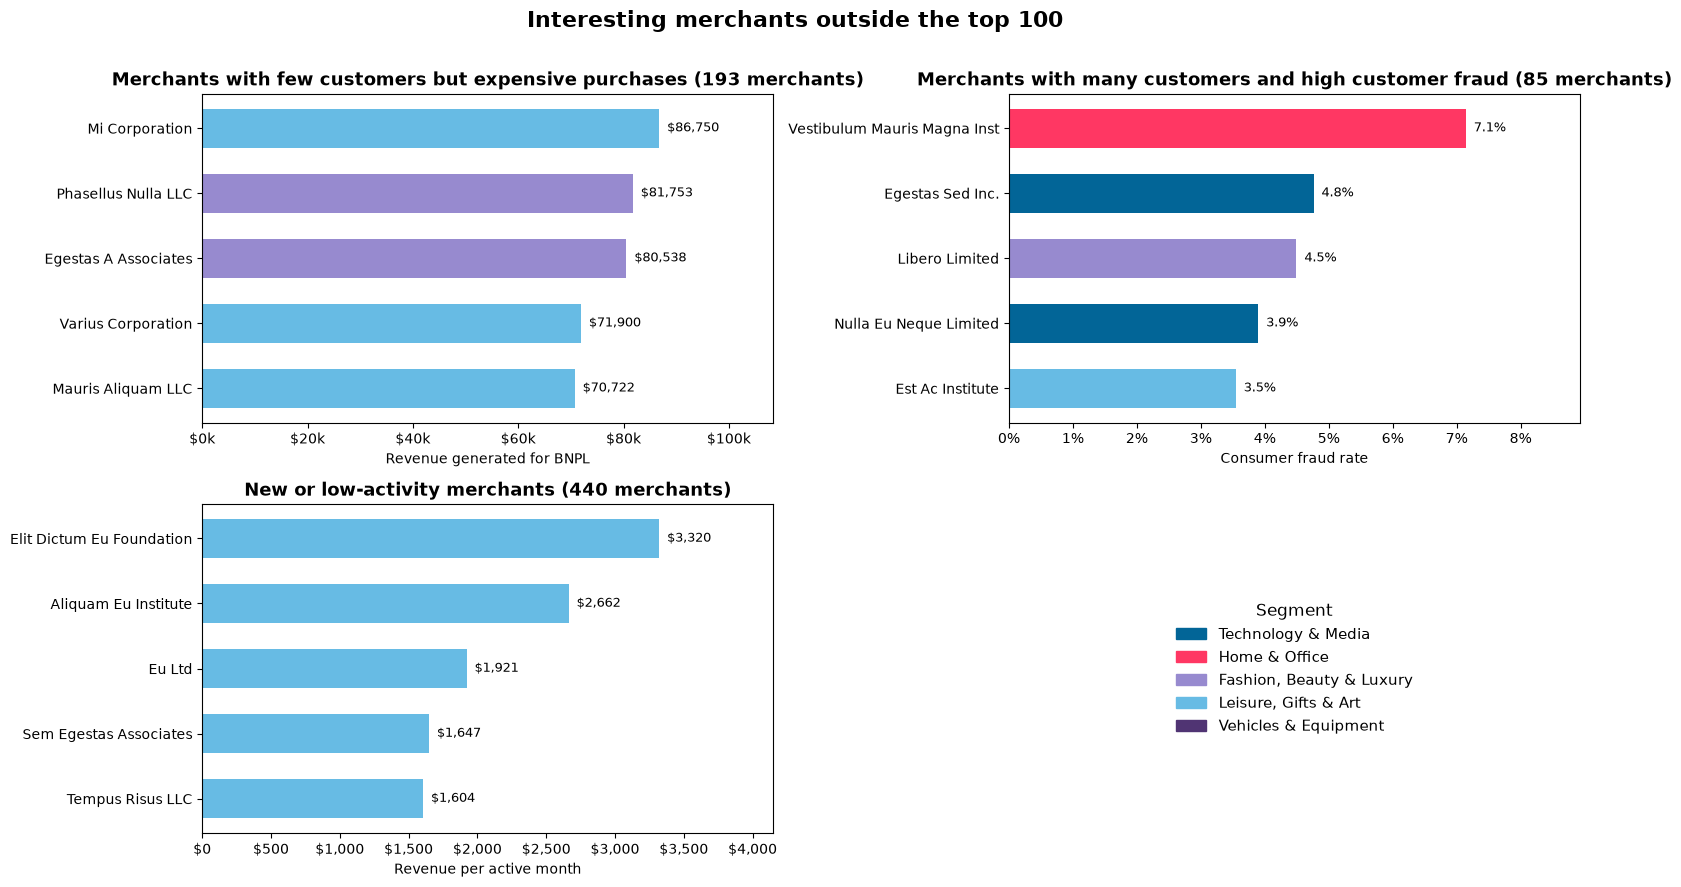

In [35]:
# This are merchants outside the top 100, but interesting for other reasons. We plot the top 5 in each group.
money = FuncFormatter(lambda x, _: f"${x / 1000:,.0f}k")
money_small = FuncFormatter(lambda x, _: f"${x:,.0f}")
percent = FuncFormatter(lambda x, _: f"{x:.0%}")

charts = [
    # title, file, column to plot, axis label, axis format, value label
    ("Merchants with few customers but expensive purchases", "interesting_small_base_big_ticket.csv",
     "est_revenue", "Revenue generated for BNPL", money, lambda v: f"${v:,.0f}"),
    ("Merchants with many customers and high customer fraud", "interesting_large_base_fraud.csv",
     "consumer_fraud_rate", "Consumer fraud rate", percent, lambda v: f"{v:.1%}"),
    ("New or low-activity merchants", "interesting_little_information.csv",
     "revenue_per_active_month", "Revenue per active month", money_small, lambda v: f"${v:,.0f}"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for ax, (title, file, col, xlabel, fmt, label) in zip(axes.flat, charts):
    path = CURATED / file
    if not path.exists():
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.text(0.5, 0.5, "File not found: run final_ranking.ipynb", ha="center", va="center")
        ax.axis("off")
        continue
    g = pd.read_csv(path, dtype={"merchant_abn": str})
    top = g.nlargest(5, col).sort_values(col)                       # highest at the top
    names = top["merchant_name"].fillna(top["merchant_abn"]).str.slice(0, 28)

    bars = ax.barh(names, top[col], color=top["segment"].map(SEGMENT_COLORS).fillna("grey"), height=0.6)
    for bar, v in zip(bars, top[col]):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f"  {label(v)}", va="center", fontsize=9)

    ax.set_xlim(0, top[col].max() * 1.25)                            # room for the labels
    ax.xaxis.set_major_formatter(fmt)
    ax.set_xlabel(xlabel)
    ax.set_title(f"{title} ({len(g)} merchants)", fontsize=13, fontweight="bold")

# fourth panel: segment legend
legend_ax = axes.flat[3]
legend_ax.axis("off")
legend_ax.legend(handles=[Patch(color=c, label=s) for s, c in SEGMENT_COLORS.items()],
                 loc="center", frameon=False, fontsize=11, title="Segment", title_fontsize=12)

fig.suptitle("Interesting merchants outside the top 100", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

- Leisure, Gifts and Art have merchants that generate high revenue, but they are outside the ranking because they don't have high demand.

- Technology and Media have merchants with high revenue, but they can't be trusted because they have a high number of fraudulent customers.

- Leisure, Gifts and Art have most of the merchants who rarely have transactions.

## Where do the customers of the top 100 merchants live?

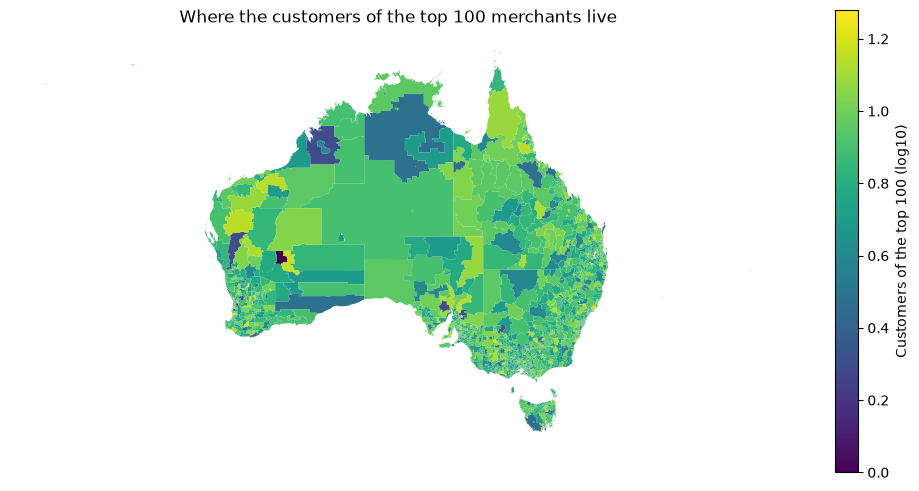

Postcodes with customers of the top 100: 3165


In [36]:
top_ids = top100["merchant_abn"].tolist()
cust = (
    spark.read.parquet("../data/curated/final_external_enriched")
    .filter(F.col("merchant_abn").isin(top_ids))
    .groupBy("postcode")
    .agg(F.countDistinct("consumer_id").alias("customers"))
    .toPandas()
)
cust["postcode"] = cust["postcode"].astype(str).str.zfill(4)

poa_path = Path("../data/landing/POA_2021_AUST_GDA2020.shp")
poa = gpd.read_file(poa_path)[["POA_CODE21", "geometry"]].rename(columns={"POA_CODE21": "postcode"})
geo = poa.merge(cust, on="postcode", how="left")
geo["log10_customers"] = np.log10(geo["customers"])

fig, ax = plt.subplots(figsize=(10, 8))
geo.plot(column="log10_customers", cmap="viridis", legend=True, ax=ax,
         legend_kwds={"label": "Customers of the top 100 (log10)", "shrink": 0.6},
         missing_kwds={"color": "lightgrey"})
ax.set_title("Where the customers of the top 100 merchants live")
ax.set_axis_off()
plt.tight_layout()
plt.show()

print("Postcodes with customers of the top 100:", cust["postcode"].nunique())

There is no clear pattern to determine a specific area where the customers of the top 100 merchants live.

In [37]:
# share of customers by state: top 100 merchants vs all merchants
enr = spark.read.parquet("../data/curated/final_external_enriched")
by_state = pd.DataFrame({
    "customers of the top 100 (%)": enr.filter(F.col("merchant_abn").isin(top_ids))
        .groupBy("state").agg(F.countDistinct("consumer_id").alias("n")).toPandas().set_index("state")["n"],
    "all customers (%)": enr.groupBy("state").agg(F.countDistinct("consumer_id").alias("n"))
        .toPandas().set_index("state")["n"],
})
by_state = (by_state / by_state.sum() * 100).round(1).sort_values("all customers (%)", ascending=False)
print(by_state)

       customers of the top 100 (%)  all customers (%)
state                                                 
NSW                            28.9               28.9
VIC                            23.1               23.1
WA                             15.8               15.8
QLD                            14.8               14.8
SA                             11.4               11.4
TAS                             3.7                3.7
NT                              1.4                1.4
ACT                             0.9                0.9


# Overall
The ranking can choose the top 100 merchants and the top 10 for each segment. However, it is important to note that during the feature analysis, it was seen that some of the features, such as demographics, don't have a big impact on how the ranking is decided. Even when we tried to change the weights of these, we saw that the merchant's position didn't move. Nonetheless, we keep these features as a business decision.

In addition to this, we also acknowledge the fact that there is a limitation towards the `is_fraud` column, since the model was trained on a few merchants. For this reason, the merchants with a recorded high probability from the original dataset are excluded. The merchants that were flagged are kept, but we penalise them, depending on their calculated fraud probability. After this, we combine it with the fraud probability of consumers according to the consumer fraud rate (fraudulent transactions / labelled transactions).


We also decided to vary the weight of demand, since low demand is not always a bad indicator, depending on the segment. This depends on the context of each segment and how the relationship is with revenue. For instance, items that are from the vehicle segment will not necessarily need a high demand, as long as their revenue continues to be high.

Finally, it was observed that around the top 20 merchants, the ranking is more stable. However, the difference between scores for the merchants that are in lower positions of the ranking is small, which means that a small change in the ranking could move them from one position to another.

# Limitations
- Fraud data had to be generated by a model due to the NULL values in the original dataset.

- Business rules: Essential products and demographics do not separate merchants in the data.

- The cut-off at 100 is sensitive, since merchants just below the 100 position, are almost as good as the others.